# Kalshi Extreme-Price Strategy
Full pipeline: fetch → filter → backtest

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())  # make sure local modules are found

from dotenv import load_dotenv
load_dotenv()

from fetch import fetch_dataset, load_dataset, Dataset
from filters import FilterConfig, scan_opportunities, summarize_opportunities
from backtest import BacktestConfig, run_backtest, print_report
import pandas as pd

os.environ["KALSHI_API_KEY_ID"] = "API KEY"
os.environ["KALSHI_PRIVATE_KEY_PATH"] = r"C:\Users\ezhu1\KalshiBot\Docs\READ_ONLY.txt"

load_dotenv("my.env")

False

## Step 1: Fetch data
Run once. After `data.pkl` exists, skip to Step 2.

In [2]:
ds = load_dataset([r"C:\Users\ezhu1\KalshiBot\Sports.pkl", r"C:\Users\ezhu1\KalshiBot\Entertainment.pkl",
                    r"C:\Users\ezhu1\KalshiBot\Trump.pkl", r"C:\Users\ezhu1\KalshiBot\Sports_1.pkl"])

print(ds.summary())

Dataset: 3370 markets, 3370 with candles (26752 total candle rows), fetched 2026-04-26T06:03:58.672631+00:00, 2026-04-26T06:37:13.719264+00:00, 2026-04-26T11:32:00.596363+00:00, 2026-04-26T11:37:49.471559+00:00


In [3]:
# Inspect the markets DataFrame
ds.markets_df.head(10)

,ticker,title,subtitle,status,result,series_ticker,event_ticker,close_time,yes_bid,yes_ask,volume,open_interest
0,KXUFCFIGHT-26APR25FILDUR-FIL,Will Jafel Filho win the Filho vs Durden profe...,None,finalized,no,None,KXUFCFIGHT-26APR25FILDUR,2026-04-25T23:01:30Z,0.00,0.01,0.0,0.0
1,KXUFCFIGHT-26APR25FILDUR-DUR,Will Cody Durden win the Filho vs Durden profe...,None,finalized,yes,None,KXUFCFIGHT-26APR25FILDUR,2026-04-25T23:01:30Z,0.99,1.00,0.0,0.0
2,KXUFCFIGHT-26APR25GRIVAL-VAL,Will Victor Valenzuela win the Griffin vs Vale...,None,finalized,yes,None,KXUFCFIGHT-26APR25GRIVAL,2026-04-25T22:15:39Z,0.99,1.00,0.0,0.0
3,KXUFCFIGHT-26APR25GRIVAL-GRI,Will Max Griffin win the Griffin vs Valenzuela...,None,finalized,no,None,KXUFCFIGHT-26APR25GRIVAL,2026-04-25T22:15:39Z,0.00,0.01,0.0,0.0
4,KXUFCFIGHT-26APR25MARBRE-MAR,Will Francis Marshall win the Marshall vs Bren...,None,finalized,yes,None,KXUFCFIGHT-26APR25MARBRE,2026-04-25T22:31:29Z,0.99,1.00,0.0,0.0
5,KXUFCFIGHT-26APR25MARBRE-BRE,Will Lucas Brennan win the Marshall vs Brennan...,None,finalized,no,None,KXUFCFIGHT-26APR25MARBRE,2026-04-25T22:31:29Z,0.00,0.01,0.0,0.0
6,KXUFCFIGHT-26APR25GARHER-HER,Will Alexander Hernandez win the Garcia vs Her...,None,finalized,no,None,KXUFCFIGHT-26APR25GARHER,2026-04-26T02:10:49Z,0.00,0.01,0.0,0.0
7,KXUFCFIGHT-26APR25GARHER-GAR,Will Rafa Garcia win the Garcia vs Hernandez p...,None,finalized,yes,None,KXUFCFIGHT-26APR25GARHER,2026-04-26T02:10:49Z,0.99,1.00,0.0,0.0
8,KXUFCFIGHT-26APR25DUMEDW-EDW,Will Joselyne Edwards win the Dumont Viana vs ...,None,finalized,yes,None,KXUFCFIGHT-26APR25DUMEDW,2026-04-26T02:45:36Z,0.99,1.00,0.0,0.0
9,KXUFCFIGHT-26APR25DUMEDW-DUM,Will Norma Dumont Viana win the Dumont Viana v...,None,finalized,no,None,KXUFCFIGHT-26APR25DUMEDW,2026-04-26T02:45:36Z,0.00,0.01,0.0,0.0


In [4]:
# Settlement result breakdown
ds.markets_df['result'].value_counts()

result
no        2234
yes       1102
scalar      34
Name: count, dtype: int64

In [5]:
# Inspect candles for one market
sample_ticker = ds.markets_df['ticker'].iloc[0]
print(f'Candles for {sample_ticker}:')
ds.candles.get(sample_ticker, pd.DataFrame()).head(10)

Candles for KXUFCFIGHT-26APR25FILDUR-FIL:


,ticker,end_period_ts,volume_fp,open_interest_fp,open_dollars,high_dollars,low_dollars,close_dollars,mean_dollars,timestamp
0,KXUFCFIGHT-26APR25FILDUR-FIL,1776830400,5119.31,4862.37,0.8300,0.9500,0.2100,0.8400,0.6711,2026-04-22 04:00:00
1,KXUFCFIGHT-26APR25FILDUR-FIL,1776916800,1157.15,5515.77,0.8400,0.8700,0.8400,0.8600,0.8518,2026-04-23 04:00:00
2,KXUFCFIGHT-26APR25FILDUR-FIL,1777003200,2342.79,7792.28,0.8400,0.8600,0.8400,0.8600,0.8500,2026-04-24 04:00:00
3,KXUFCFIGHT-26APR25FILDUR-FIL,1777089600,2323.16,10036.43,0.8600,0.8600,0.8400,0.8500,0.8538,2026-04-25 04:00:00
4,KXUFCFIGHT-26APR25FILDUR-FIL,1777176000,429402.02,290101.79,0.8500,0.8700,0.0100,0.0100,0.5124,2026-04-26 04:00:00


In [6]:
candles_df = ds.candles.get(sample_ticker, pd.DataFrame())
candles_df['datetime'] = pd.to_datetime(candles_df['end_period_ts'], unit='s')
candles_df.head(10)

,ticker,end_period_ts,volume_fp,open_interest_fp,open_dollars,high_dollars,low_dollars,close_dollars,mean_dollars,timestamp,datetime
0,KXUFCFIGHT-26APR25FILDUR-FIL,1776830400,5119.31,4862.37,0.8300,0.9500,0.2100,0.8400,0.6711,2026-04-22 04:00:00,2026-04-22 04:00:00
1,KXUFCFIGHT-26APR25FILDUR-FIL,1776916800,1157.15,5515.77,0.8400,0.8700,0.8400,0.8600,0.8518,2026-04-23 04:00:00,2026-04-23 04:00:00
2,KXUFCFIGHT-26APR25FILDUR-FIL,1777003200,2342.79,7792.28,0.8400,0.8600,0.8400,0.8600,0.8500,2026-04-24 04:00:00,2026-04-24 04:00:00
3,KXUFCFIGHT-26APR25FILDUR-FIL,1777089600,2323.16,10036.43,0.8600,0.8600,0.8400,0.8500,0.8538,2026-04-25 04:00:00,2026-04-25 04:00:00
4,KXUFCFIGHT-26APR25FILDUR-FIL,1777176000,429402.02,290101.79,0.8500,0.8700,0.0100,0.0100,0.5124,2026-04-26 04:00:00,2026-04-26 04:00:00


In [7]:
markets = ds.markets_df['ticker'].str.split('-', n=1).str[0]
print(markets.value_counts())

ticker
KXUFCFIGHT               200
KXNBAGAME                200
KXLIGAMXGAME             200
KXITFMATCH               200
KXWTACHALLENGERMATCH     200
KXNASCARRACE             200
KXLOLGAME                200
KXSPOTIFY2D              200
KXEPLGAME                200
KXPGATOUR                200
KXSERIEAGAME             200
KXDPWORLDTOUR            200
KXCS2GAME                200
KXWTAMATCH               192
KXRT                     173
KXUCLGAME                108
KXTRUTHSOCIAL             81
KXIPLGAME                 74
KXRANKLISTSONGSPOTUSA     66
KXUFLGAME                 28
KXEOWEEK                  17
KXNHL                     16
KXVOTEHUBTRUMPUPDOWN      10
KXSNLHOST                  5
Name: count, dtype: int64


## Step 2: Filter — find trade opportunities

In [253]:
filter_config = FilterConfig(
    yes_max=0.15,            # buy NO when YES price ≤ yes_max%
    yes_min=0.9,            # buy YES when YES price ≥ yes_min%
    min_candle_volume=0,     # no per-candle volume floor
    min_open_interest=0,     # no OI floor
    min_market_volume=500,   # skip thin markets
    min_hours_to_expiry=0.1, # don't enter in final hour
    max_hours_to_expiry=120,   # no upper limit
    entry_mode='first',      # first qualifying candle per market
    cutoff=0.05              # ignore prices between 2% and 98% (dead zone)
)

opportunities = scan_opportunities(ds.markets_df, ds.candles, filter_config)
summarize_opportunities(opportunities, filter_config)


OPPORTUNITY SCAN RESULTS
Filters: YES ≤ 15% (buy NO) | YES ≥ 90% (buy YES)
         volume ≥ 0 | OI ≥ 0 | time-to-expiry ≥ 0.1h
Mode:    first

Total opportunities: 380
Unique markets:      380

  NO side: 304 entries
    Avg YES mid:       0.102
    Avg entry price:   0.898
    Avg hours to exp:  71.3
    Win rate (preview): 92.8%

  YES side: 76 entries
    Avg YES mid:       0.925
    Avg entry price:   0.925
    Avg hours to exp:  47.9
    Win rate (preview): 94.7%

Sample opportunities:
                      ticker side  yes_mid  entry_price  hours_to_expiry market_result
KXUFCFIGHT-26APR04YAKRIB-YAK  YES   0.9029       0.9029            117.9           yes
KXUFCFIGHT-26APR04YAKRIB-RIB   NO   0.1220       0.8780            117.9            no
KXUFCFIGHT-26APR04MCMZEC-ZEC   NO   0.0958       0.9042            117.4            no
KXUFCFIGHT-26APR04MCMZEC-MCM  YES   0.9135       0.9135            117.4           yes
KXUFCFIGHT-26MAR21PINFRA-FRA   NO   0.1439       0.8561            

In [254]:
opportunities['market'] = opportunities['ticker'].str.split('-', n=1).str[0]
opportunities['market'].value_counts()

market
KXRT                     61
KXTRUTHSOCIAL            53
KXNASCARRACE             42
KXNBAGAME                41
KXLOLGAME                26
KXSERIEAGAME             23
KXLIGAMXGAME             19
KXPGATOUR                18
KXWTAMATCH               17
KXUCLGAME                16
KXEPLGAME                11
KXCS2GAME                10
KXRANKLISTSONGSPOTUSA     9
KXUFCFIGHT                6
KXWTACHALLENGERMATCH      6
KXITFMATCH                5
KXVOTEHUBTRUMPUPDOWN      5
KXDPWORLDTOUR             4
KXSNLHOST                 4
KXEOWEEK                  3
KXUFLGAME                 1
Name: count, dtype: int64

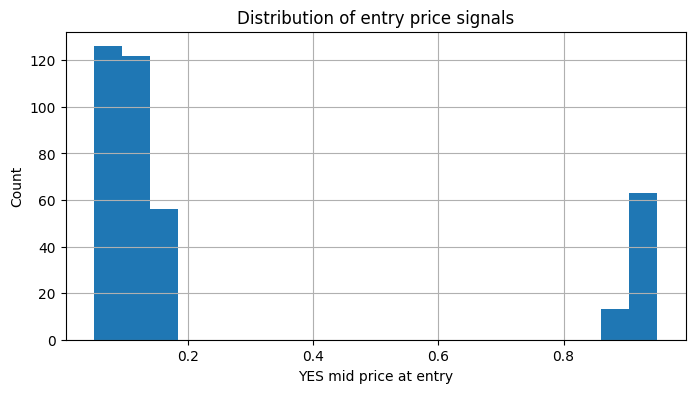

In [255]:
# Distribution of entry prices
opportunities['yes_mid'].hist(bins=20, figsize=(8, 4))
import matplotlib.pyplot as plt
plt.xlabel('YES mid price at entry')
plt.ylabel('Count')
plt.title('Distribution of entry price signals')
plt.show()

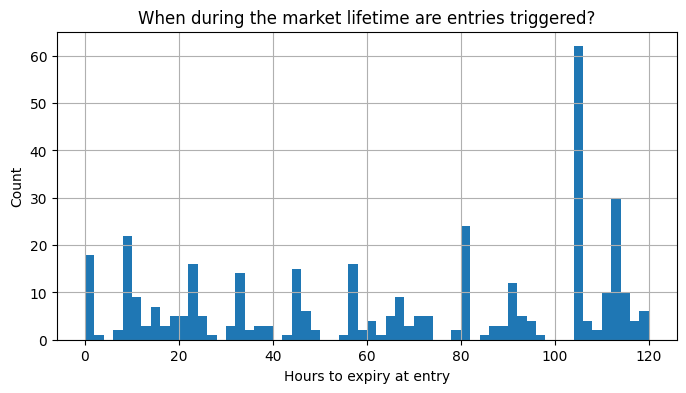

In [256]:
# Hours-to-expiry distribution
opportunities['hours_to_expiry'].hist(bins=60, figsize=(8, 4))
plt.xlabel('Hours to expiry at entry')
plt.ylabel('Count')
plt.title('When during the market lifetime are entries triggered?')
plt.show()

## Step 3: Backtest

In [282]:
filtered_opportunities = opportunities[
    opportunities['ticker'].str.contains(
        r'KXNBAGAME|KXRT|KXLOLGAME|KXSPOTIFYSONG|KXUFCFIGHT|KXITFMATCH|KXWTACHALLENGERMATCH|KXRANKLISTSONGSPOTUSA|KXVOTEHUBTRUMPUPDOWN',
        na=False
    )
]

filtered_opportunities = opportunities[
    opportunities['ticker'].str.contains(
        r'KXNBAGAME|KXRT|KXLOLGAME|KXITFMATCH|KXLIGAMXGAME|KXWTACHALLENGERMATCH|KXUFCFIGHT|KXRANKLISTSONGSPOTUSA|KXVOTEHUBTRUMPUPDOWN|KXSNLHOST',
        na=False
    )
]

print(len(opportunities), "total opportunities found")
print(len(filtered_opportunities), "opportunities after filtering for specific markets")

380 total opportunities found
182 opportunities after filtering for specific markets


In [283]:
backtest_config = BacktestConfig(
    bankroll=100.0,
    sizing_mode='fixed_dollar',  # 'fixed_pct', 'fixed_dollar', 'kelly'
    fixed_dollar=2,          # $10 per trade
    fixed_pct=0.02,           # 5% of bankroll per trade
    #kelly_edge_assumption=0.5,
    #kelly_fraction=0.5,
    role='taker',             # 'taker' or 'maker'
)

results = run_backtest(opportunities, backtest_config)
print_report(results)


BACKTEST REPORT

Config: sizing=fixed_dollar, role=taker, bankroll=$100
        $2 per trade

380 trades | Win rate: 93.2% | P&L: $+13.94 | ROI: +13.9% | Max DD: 4.8% | Sharpe: 1.20 | Profit factor: 1.29 | Final: $113.94

By side:
  Side    Trades   Wins    Win%        P&L  Avg Entry
  --------------------------------------------------
  NO         304    282   92.8% $   +12.00      0.898
  YES         76     72   94.7% $    +1.94      0.925

First 15 trades:
  Ticker                              Side  Entry    YES  W      P&L     Bank
  ---------------------------------------------------------------------------
  KXUCLGAME-26FEB18QARNEW-QAR         NO    0.850  0.150  ✓ $  +0.28 $     98
  KXTRUTHSOCIAL-26FEB21-B149          NO    0.859  0.141  ✗ $  -1.74 $     97
  KXTRUTHSOCIAL-26FEB21-B129          NO    0.885  0.115  ✓ $  +0.21 $     95
  KXTRUTHSOCIAL-26FEB21-B189          NO    0.855  0.145  ✓ $  +0.27 $     93
  KXTRUTHSOCIAL-26FEB21-B210          NO    0.880  0.120  ✓ $  +0.2

In [289]:
backtest_config = BacktestConfig(
    bankroll=100.0,
    sizing_mode='fixed_pct',  # 'fixed_pct', 'fixed_dollar', 'kelly'
    fixed_dollar=10,          # $10 per trade
    fixed_pct=0.02,           # 5% of bankroll per trade
    #kelly_edge_assumption=0.5,
    #kelly_fraction=0.5,
    role='taker',             # 'taker' or 'maker'
)

results = run_backtest(filtered_opportunities, backtest_config)
print_report(results)


BACKTEST REPORT

Config: sizing=fixed_pct, role=taker, bankroll=$100
        2% of bankroll per trade

182 trades | Win rate: 98.4% | P&L: $+26.62 | ROI: +26.6% | Max DD: 2.8% | Sharpe: 8.80 | Profit factor: 6.08 | Final: $126.62

By side:
  Side    Trades   Wins    Win%        P&L  Avg Entry
  --------------------------------------------------
  NO         121    118   97.5% $   +18.48      0.889
  YES         61     61  100.0% $    +8.14      0.923

First 15 trades:
  Ticker                              Side  Entry    YES  W      P&L     Bank
  ---------------------------------------------------------------------------
  KXRT-HOW-75                         NO    0.892  0.108  ✓ $  +0.20 $     98
  KXVOTEHUBTRUMPUPDOWN-26FEB19        NO    0.903  0.097  ✓ $  +0.17 $     96
  KXRT-HOW-62                         NO    0.936  0.064  ✓ $  +0.11 $     94
  KXRT-HOW-60                         NO    0.915  0.085  ✓ $  +0.15 $     95
  KXRT-HOW-52                         NO    0.913  0.086  

In [273]:
trades_df = results.trades_df.sort_values('timestamp')
trades_df['datetime'] = pd.to_datetime(trades_df['timestamp'], unit='s')
trades_df.set_index('datetime', inplace=True)
trades_df['market'] = trades_df['ticker'].str.split('-', n=1).str[0]

sample_period = pd.Timedelta(trades_df.index[-1] - trades_df.index[0])
print(f'Trades were executed over a period of {sample_period.days} days.')


Trades were executed over a period of 67 days.


In [274]:
print('Summary statistics for YES mid price at entry, by side:')
print('NO side \n', trades_df.loc[trades_df['side'] == 'NO']['yes_mid'].describe())

print('YES side \n', trades_df.loc[trades_df['side'] == 'YES']['yes_mid'].describe())


Summary statistics for YES mid price at entry, by side:
NO side 
 count    123.000000
mean       0.143030
std        0.043456
min        0.051900
25%        0.112250
50%        0.149000
75%        0.180300
max        0.200000
Name: yes_mid, dtype: float64
YES side 
 count    39.000000
mean      0.924123
std       0.015493
min       0.900600
25%       0.912050
50%       0.925100
75%       0.936450
max       0.949400
Name: yes_mid, dtype: float64


In [275]:
trades_df['market'].value_counts()

market
KXRT                     46
KXNBAGAME                32
KXLIGAMXGAME             30
KXUFCFIGHT               16
KXLOLGAME                12
KXRANKLISTSONGSPOTUSA     7
KXVOTEHUBTRUMPUPDOWN      6
KXWTACHALLENGERMATCH      6
KXITFMATCH                4
KXSNLHOST                 3
Name: count, dtype: int64

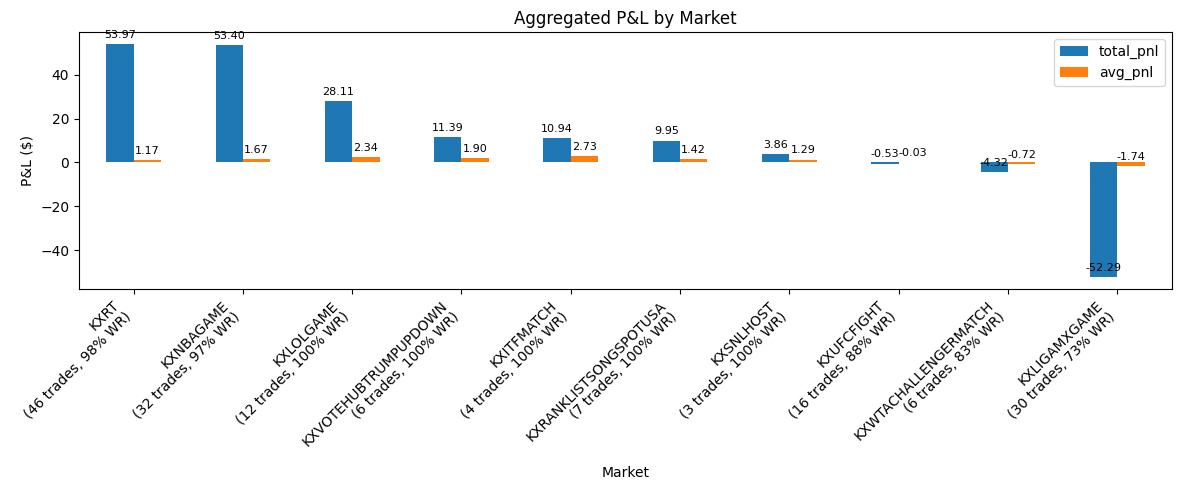

In [276]:
market_stats = trades_df.groupby('market').agg(
    total_pnl=('pnl', 'sum'),
    avg_pnl=('pnl', 'mean'),
    trade_count=('pnl', 'count'),
    win_rate=('won', 'mean')
).sort_values('total_pnl', ascending=False)

ax = market_stats[['total_pnl', 'avg_pnl']].plot(kind='bar', figsize=(12, 5))

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        xy=(p.get_x() + p.get_width() / 2, p.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=8
    )

ax.set_xticklabels(
    [f"{market}\n({count} trades, {wr:.0%} WR)" for market, count, wr in zip(market_stats.index, market_stats['trade_count'], market_stats['win_rate'])],
    rotation=45,
    ha='right'
)

plt.xlabel('Market')
plt.ylabel('P&L ($)')
plt.title('Aggregated P&L by Market')
plt.tight_layout()
plt.show()

                      mean       std  count      min     max
hours_to_expiry                                             
(-0.0199, 12.09]  1.118204  4.293259     23 -16.0797  3.0419
(12.09, 24.08]    1.726650  0.665185     14   0.5753  2.5750
(24.08, 36.07]   -0.153133  5.268348     12 -13.3840  3.0400
(36.07, 48.06]    0.325792  5.190983     24 -14.0760  2.9020
(48.06, 60.05]    1.599882  0.760042     11   0.4895  2.8633
(60.05, 72.04]   -1.559092  7.121031     13 -17.2000  2.7540
(72.04, 84.03]   -0.145317  4.469592     12 -14.2800  1.8821
(84.03, 96.02]    1.904590  0.695796     10   0.7830  2.8432
(96.02, 108.01]   1.080407  2.653546     29 -12.4755  2.4768
(108.01, 120.0]   0.902336  3.900026     14 -12.6420  2.1280


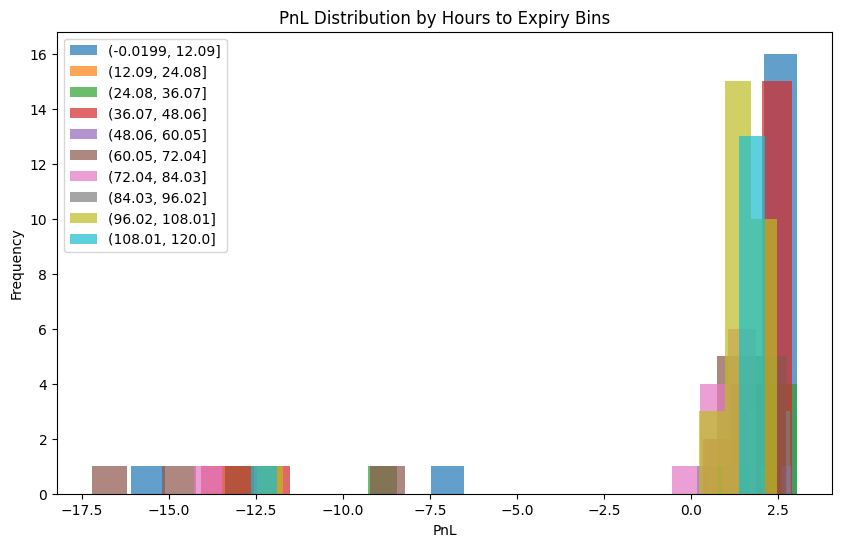

In [277]:
# Bin hours_to_expiry into categories (e.g., quartiles or custom bins)
bins = pd.cut(trades_df['hours_to_expiry'], bins=10)  # Adjust bins as needed

# Group by bins and calculate pnl stats
pnl_stats = trades_df.groupby(bins, observed=True)['pnl'].agg(['mean', 'std', 'count', 'min', 'max'])
print(pnl_stats)

# Plot pnl distribution by bin
trades_df.groupby(bins, observed=True)['pnl'].plot(kind='hist', alpha=0.7, bins=20, figsize=(10, 6), legend=True)
plt.xlabel('PnL')
plt.ylabel('Frequency')
plt.title('PnL Distribution by Hours to Expiry Bins')
plt.show()

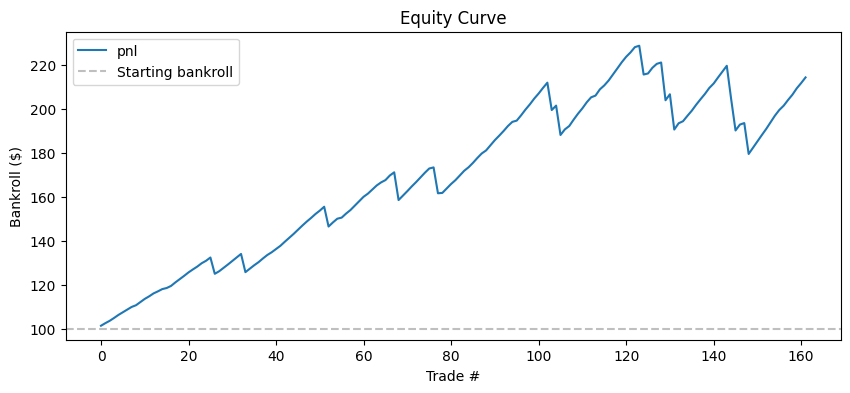

In [278]:
# Equity curve
equity = backtest_config.bankroll + results.trades_df['pnl'].cumsum()
equity.plot(figsize=(10, 4))
plt.axhline(y=backtest_config.bankroll, color='gray', linestyle='--', alpha=0.5, label='Starting bankroll')
plt.xlabel('Trade #')
plt.ylabel('Bankroll ($)')
plt.title('Equity Curve')
plt.legend()
plt.show()

In [267]:
"""# P&L by series
if 'series_ticker' in results.trades_df.columns:
    results.trades_df.groupby('series_ticker')['pnl'].sum().sort_values().plot(
        kind='barh', figsize=(8, 4)
    )
    plt.xlabel('Total P&L ($)')
    plt.title('P&L by Series')
    plt.tight_layout()
    plt.show()"""

"# P&L by series\nif 'series_ticker' in results.trades_df.columns:\n    results.trades_df.groupby('series_ticker')['pnl'].sum().sort_values().plot(\n        kind='barh', figsize=(8, 4)\n    )\n    plt.xlabel('Total P&L ($)')\n    plt.title('P&L by Series')\n    plt.tight_layout()\n    plt.show()"

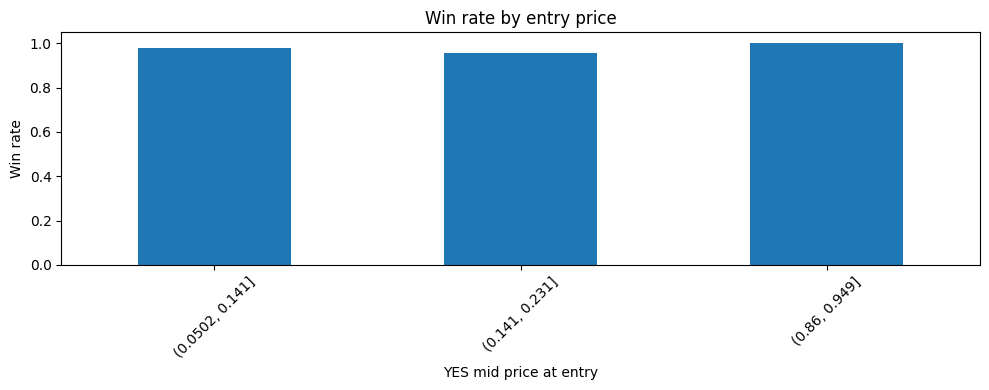

In [268]:
# Win rate vs entry price — does the edge vary by how extreme the price is?
bins = pd.cut(results.trades_df['yes_mid'], bins=10)
results.trades_df.groupby(bins, observed=True)['won'].mean().plot(
    kind='bar', figsize=(10, 4)
)
plt.xlabel('YES mid price at entry')
plt.ylabel('Win rate')
plt.title('Win rate by entry price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Parameter sweep

In [269]:
# Sweep entry thresholds — find what's robust
sweep_rows = []
for low in [0.08, 0.12, 0.15, 0.2]:
    for high in [0.80, 0.85, 0.90]:
        fc = FilterConfig(yes_max=low, yes_min=high, min_market_volume=500, entry_mode='first', cutoff=0.05,
                          min_hours_to_expiry=0.1,  max_hours_to_expiry=120)
        opps = scan_opportunities(ds.markets_df, ds.candles, fc)
        if opps.empty:
            continue
        filtered_opportunities = opps[
            opps['ticker'].str.contains(
                r'KXNBAGAME|KXRT|KXLOLGAME|KXITFMATCH|KXLIGAMXGAME|KXWTACHALLENGERMATCH|KXUFCFIGHT|KXRANKLISTSONGSPOTUSA|KXVOTEHUBTRUMPUPDOWN|KXSNLHOST',
                na=False
            )
        ]
        r = run_backtest(filtered_opportunities, backtest_config)
        sweep_rows.append({
            'yes_max': low, 'yes_min': high,
            'trades': r.total_trades,
            'win_rate': r.win_rate,
            'roi': r.roi,
            'sharpe': r.sharpe,
            'profit_factor': r.profit_factor,
        })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.sort_values('roi', ascending=False)

,yes_max,yes_min,trades,win_rate,roi,sharpe,profit_factor
7,0.15,0.85,244,0.954918,0.275396,4.169839,2.437469
8,0.15,0.90,182,0.983516,0.266164,8.802914,6.078690
6,0.15,0.80,291,0.931271,0.227271,2.801616,1.544527
4,0.12,0.85,204,0.960784,0.216174,4.196270,2.553242
5,0.12,0.90,142,1.000000,0.209742,54.683934,inf
3,0.12,0.80,251,0.932271,0.193604,2.553887,1.616589
10,0.20,0.85,310,0.909677,0.167986,1.347600,1.354513
9,0.20,0.80,357,0.896359,0.163907,1.081377,1.259325
11,0.20,0.90,248,0.919355,0.163730,1.725505,1.489222
1,0.08,0.85,159,0.949686,0.128008,2.795225,1.919756


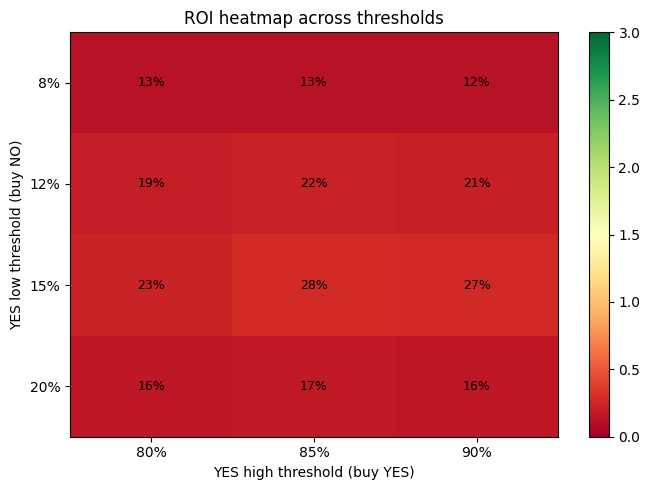

In [270]:
# Heatmap of ROI across threshold pairs
pivot = sweep_df.pivot(index='yes_max', columns='yes_min', values='roi')
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
               vmin=0.0, vmax=3)
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f'{v:.0%}' for v in pivot.columns])
ax.set_yticklabels([f'{v:.0%}' for v in pivot.index])
ax.set_xlabel('YES high threshold (buy YES)')
ax.set_ylabel('YES low threshold (buy NO)')
ax.set_title('ROI heatmap across thresholds')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=9)
plt.colorbar(im)
plt.tight_layout()
plt.show()

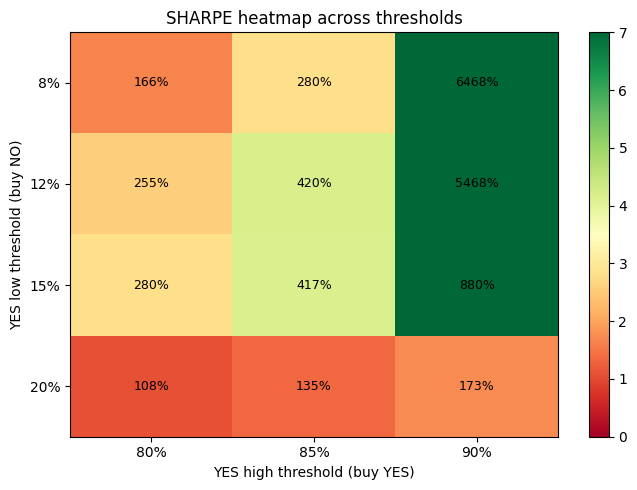

In [271]:
# Heatmap of ROI across threshold pairs
pivot = sweep_df.pivot(index='yes_max', columns='yes_min', values='sharpe')
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
               vmin=0, vmax=7)
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f'{v:.0%}' for v in pivot.columns])
ax.set_yticklabels([f'{v:.0%}' for v in pivot.index])
ax.set_xlabel('YES high threshold (buy YES)')
ax.set_ylabel('YES low threshold (buy NO)')
ax.set_title('SHARPE heatmap across thresholds')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=9)
plt.colorbar(im)
plt.tight_layout()
plt.show()